In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do Scikit-Learn baseadas no material didático
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Algoritmos que serão comparados
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from google.colab import drive
drive.mount('/content/drive')

csv_file_path = '/content/drive/MyDrive/winequalityN.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# --- 1. COLETA E CARREGAMENTO DOS DADOS ---
# Alterado para ler o arquivo .csv diretamente
df = pd.read_csv(csv_file_path)

print("=== Primeiras linhas do dataset ===")
print(df.head())

=== Primeiras linhas do dataset ===
    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide    density    pH  \
0      45.00                 45.0                 170.0  1001.0000  3.00   
1      49.00                 14.0                 132.0   994.0000  3.30   
2       0.05                 30.0                  97.0     0.9951  3.26   
3      58.00                 47.0                 186.0     0.9956  3.19   
4      58.00                 47.0                 186.0     0.9956  3.19   

   sulphates  alcohol  quality  
0       0.45      8.8        

In [20]:
# --- 2. PRÉ-PROCESSAMENTO DE DADOS ---

# 2.1 Tratamento de Elementos Faltantes (Missing Values)
# Para colunas numéricas, preenchemos com a média (boa prática de Data Science)
colunas_numericas = df.select_dtypes(include=[np.number]).columns
df[colunas_numericas] = df[colunas_numericas].fillna(df[colunas_numericas].mean())

# Para colunas categóricas (como 'type'), caso haja nulos, preenchemos com a moda
colunas_categoricas = df.select_dtypes(include=['object']).columns
for col in colunas_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2.2 Conversão de Variáveis Categóricas
# Transforma a coluna 'type' (white/red) em colunas binárias numéricas (0 ou 1)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# 2.3 Definição da Variável Alvo Categórica (Classificação)
# Conforme a lógica do problema: qualidade >= 6 vira classe 1 (Alta), < 6 vira classe 0 (Baixa) [cite: 6, 8]
df['target_quality'] = np.where(df['quality'] >= 6, 1, 0)

# Removendo a coluna original de notas para evitar vazamento de dados (data leakage) [cite: 188]
X = df.drop(columns=['quality', 'target_quality'])
y = df['target_quality']

# 2.4 Separação de Dados em Treino e Teste
# Uso do parâmetro 'stratify' para manter a proporção das classes idêntica nos dois conjuntos [cite: 195]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nProporção das classes no conjunto de treino:\n", y_train.value_counts(normalize=True))


Proporção das classes no conjunto de treino:
 target_quality
1    0.6275
0    0.3725
Name: proportion, dtype: float64


In [21]:
# --- 3. IMPLEMENTAÇÃO, TREINO E AVALIAÇÃO (MÉTODO 80 / 20) ---

# Dicionários para armazenar as métricas obtidas na validação do conjunto de teste (20%)
resultados_f1 = {}
matrizes_confusao = {}

# Definição dos três algoritmos com as configurações sugeridas no material de aula:
# - Regressão Logística: Recomendado normalizar [cite: 4] e boa para fronteiras lineares[cite: 4, 37].
# - KNN Classificador: Normalização obrigatória [cite: 4, 47, 220] (K=7, pesos por distância) [cite: 54, 56].
# - Árvore de Decisão: Controle de profundidade para evitar overfitting[cite: 82, 97, 98].
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN (7 Vizinhos)": KNeighborsClassifier(n_neighbors=7, weights="distance"),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
}

print("=== Treinamento (80%) e Avaliação no Teste (20%) ===")

for nome, modelo in modelos.items():
    # Construção do Pipeline para encadear o pré-processamento (StandardScaler) ao algoritmo
    # Isso garante que a normalização seja aplicada de forma segura e automatizada[cite: 48, 187].
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', modelo)
    ])

    # 3.1 Treino: Ajustando o modelo utilizando os 80% dos dados [cite: 194, 210]
    pipe.fit(X_train, y_train)

    # 3.2 Previsão: Testando o modelo nos 20% de dados invisíveis [cite: 212, 213]
    y_pred = pipe.predict(X_test)

    # 3.3 Cálculo das Métricas de Avaliação [cite: 139]
    # Armazenando o F1-Score (weighted) devido ao desbalanceamento natural das classes [cite: 132, 137]
    resultados_f1[nome] = f1_score(y_test, y_pred, average='weighted')
    matrizes_confusao[nome] = confusion_matrix(y_test, y_pred) #[cite: 157]

    # Exibição do relatório sintético detalhado para cada algoritmo [cite: 154, 155, 214]
    print(f"\n> {nome}:")
    print(classification_report(y_test, y_pred))

=== Treinamento (80%) e Avaliação no Teste (20%) ===

> Regressão Logística:
              precision    recall  f1-score   support

           0       0.60      0.41      0.48        37
           1       0.71      0.84      0.77        63

    accuracy                           0.68       100
   macro avg       0.65      0.62      0.63       100
weighted avg       0.67      0.68      0.66       100


> KNN (7 Vizinhos):
              precision    recall  f1-score   support

           0       0.70      0.43      0.53        37
           1       0.73      0.89      0.80        63

    accuracy                           0.72       100
   macro avg       0.71      0.66      0.67       100
weighted avg       0.72      0.72      0.70       100


> Árvore de Decisão:
              precision    recall  f1-score   support

           0       0.60      0.68      0.63        37
           1       0.79      0.73      0.76        63

    accuracy                           0.71       100
   macro

/tmp/ipykernel_2772/691648829.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(resultados_f1.keys()), y=list(resultados_f1.values()), palette="mako")


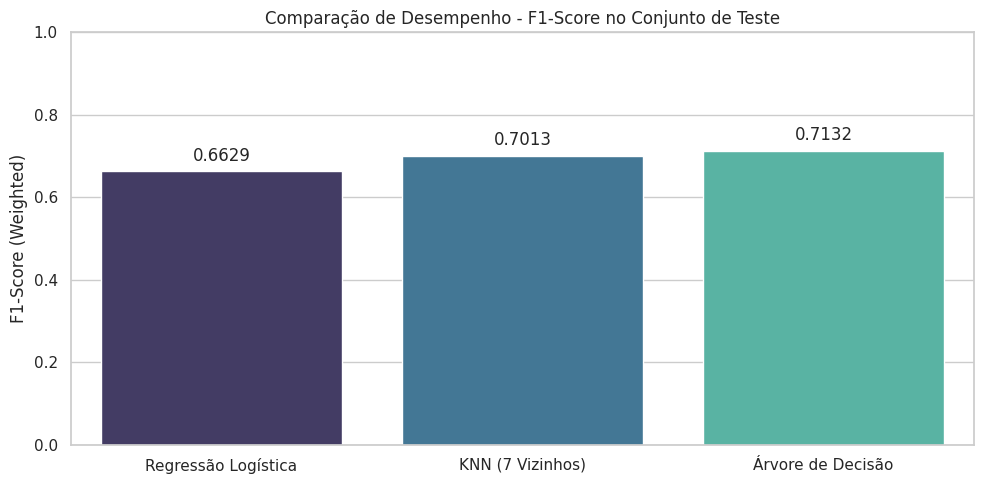

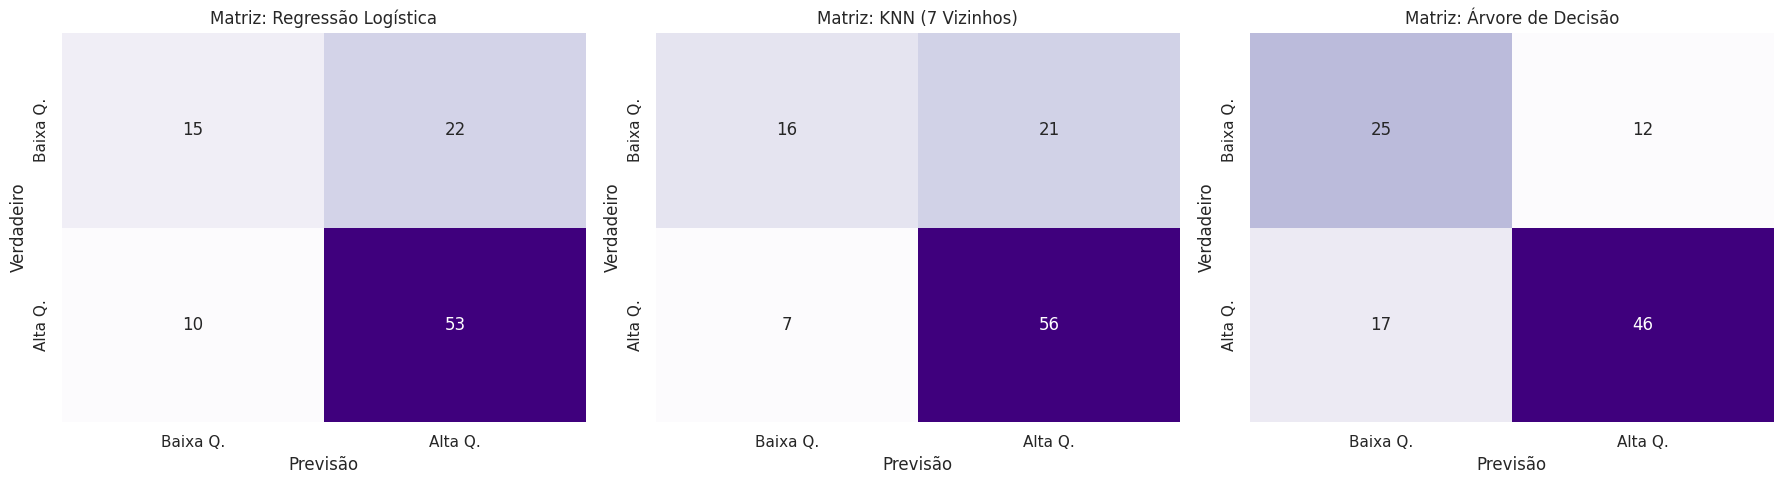

In [22]:
# --- 4. RELATÓRIO VISUAL (GRÁFICOS) ---

# Gráfico 1: Barras comparativas do F1-Score
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=list(resultados_f1.keys()), y=list(resultados_f1.values()), palette="mako")
plt.title("Comparação de Desempenho - F1-Score no Conjunto de Teste")
plt.ylabel("F1-Score (Weighted)")
plt.ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

# Gráfico 2: Matrizes de Confusão Combinadas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (nome, matrix) in enumerate(matrizes_confusao.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Purples', ax=axes[idx], cbar=False,
                xticklabels=['Baixa Q.', 'Alta Q.'], yticklabels=['Baixa Q.', 'Alta Q.'])
    axes[idx].set_title(f"Matriz: {nome}")
    axes[idx].set_xlabel("Previsão")
    axes[idx].set_ylabel("Verdadeiro")
plt.tight_layout()
plt.show()